### Using NILEARN to do fMRI decoding

In [4]:
import warnings

warnings.filterwarnings(
    "ignore", message="The provided image has no sform in its header"
)

Retrieve and load the fMRI data from Haxby study

In [1]:
from nilearn import datasets

# In default, the 2nd subject is downloaded
haxby_dataset = datasets.fetch_haxby()

fmri_filename = haxby_dataset.func[0] # func is a list of 4D nifti images, one for each subject

print(f"First subject functional nifti image (4D) is located at: {fmri_filename}")

[fetch_haxby] Dataset directory found: C:\Users\auran\nilearn_data\haxby2001

First subject functional nifti image (4D) is located at: C:\Users\auran\nilearn_data\haxby2001\subj2\bold.nii.gz


Visualizing the fMRI volume

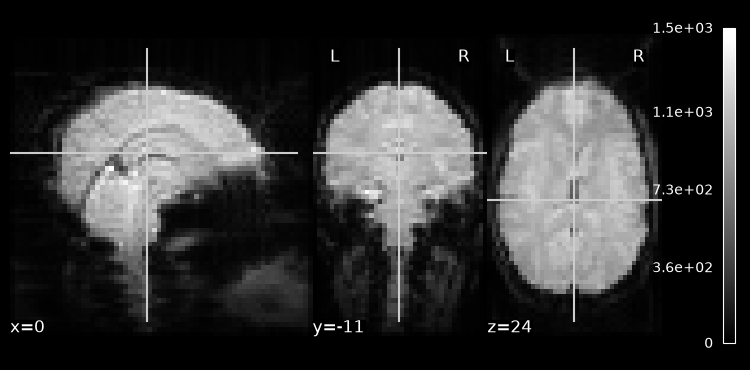

In [5]:
from nilearn.image import mean_img
from nilearn.plotting import plot_epi, plot_roi, show

# plot_anat is a function that displays anatomical images (like T1-weighted MRI scans). It takes care of displaying the image in a way that is easy to interpret, including setting the correct orientation and scaling.
# plot_epi is a convenience function that wraps around plot_anat and plot_img. It is used to plot EPI images, which are typically 4D fMRI images. The function takes care of displaying the mean image of the 4D data, which is often more informative than a single volume.
# plot_roi is a function that displays a region of interest (ROI) on top of an anatomical or functional image. It takes care of displaying the ROI in a way that is easy to interpret, including setting the correct orientation and scaling.
# show() is a function that displays the figure. It is used to display the figure after all the plotting functions have been called.

plot_epi(mean_img(fmri_filename))

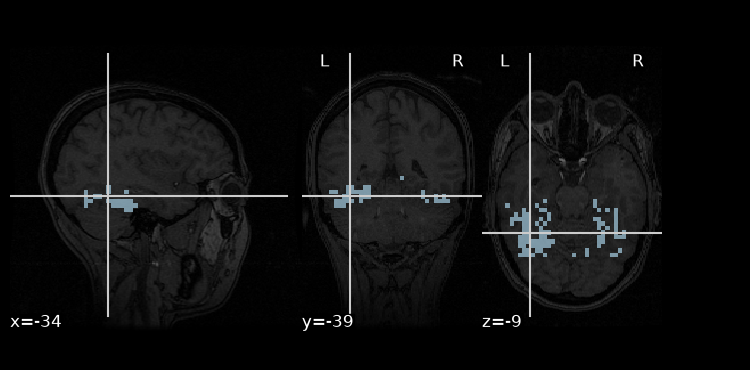

In [7]:
mask_filename = haxby_dataset.mask_vt[0] # mask_vt is a list of 3D nifti images, one for each subject
plot_roi(mask_filename, bg_img=haxby_dataset.anat[0], cmap="Paired") 
# bg_img is a parameter that specifies the background image to use for displaying the ROI. In this case, haxby_dataset.anat[0] is the anatomical image for the first subject, which is used as the background for displaying the ROI.
# cmap is a parameter that specifies the colormap to use for displaying the ROI. In this case, "Paired" is a colormap that uses pairs of colors to represent different regions in the ROI.
# other than Paired, there are many other colormaps available in matplotlib, such as "viridis", "plasma", "inferno", "magma", "cividis", etc. You can choose a colormap that best suits your data and visualization needs.

show()

Loading Behavioural Labels

In [8]:
import pandas as pd

behavioral = pd.read_csv(haxby_dataset.session_target[0], delimiter=" ")
print(behavioral)

     labels  chunks
0      rest       0
1      rest       0
2      rest       0
3      rest       0
4      rest       0
...     ...     ...
1447   rest      11
1448   rest      11
1449   rest      11
1450   rest      11
1451   rest      11

[1452 rows x 2 columns]


The task was a visual-recognition task, and the labels denote the experimental condition: the type of object that was presented to the subject. This is what we are going to try to predict.

In [9]:
conditions = behavioral["labels"]
print(conditions)

0       rest
1       rest
2       rest
3       rest
4       rest
        ... 
1447    rest
1448    rest
1449    rest
1450    rest
1451    rest
Name: labels, Length: 1452, dtype: str


Restrict the analysis to cats and faces

In [10]:
condition_mask = conditions.isin(["face", "cat"])

from nilearn.image import index_img

fmri_niimgs = index_img(fmri_filename, condition_mask)

In [11]:
conditions = conditions[condition_mask]
conditions = conditions.to_numpy()
print(f"{conditions.shape=}")

conditions.shape=(216,)
